In [97]:
!pip install nbformat

##What is KNN Imputer?

KNN Imputer stands for K-Nearest Neighbors Imputer. It is a smart technique to fill missing values (NaN) in your dataset by looking at the most similar data points and using their values to fill the gap.

📐 Distance Formula Used
KNN Imputer uses Euclidean Distance by default:
```
Distance = √[(x1-y1)² + (x2-y2)² + (x3-y3)²...]
```
Only non-missing features are used to calculate distance.

In [25]:
from sklearn.impute import KNNImputer
import pandas as pd
import numpy as np

# Sample data with missing values
data = {
    'Age':        [25, 30, np.nan, 35, 28],
    'Salary':     [50000, np.nan, 60000, 80000, 45000],
    'Experience': [3, 5, 7, np.nan, 2]
}

df = pd.DataFrame(data)
print("Before Imputation:")
print(df)

# Apply KNN Imputer
imputer = KNNImputer(n_neighbors=2)
df_imputed = imputer.fit_transform(df)

print("\nAfter Imputation:")
print(pd.DataFrame(df_imputed, columns=df.columns))


Before Imputation:
    Age   Salary  Experience
0  25.0  50000.0         3.0
1  30.0      NaN         5.0
2   NaN  60000.0         7.0
3  35.0  80000.0         NaN
4  28.0  45000.0         2.0

After Imputation:
    Age   Salary  Experience
0  25.0  50000.0         3.0
1  30.0  52500.0         5.0
2  27.5  60000.0         7.0
3  35.0  80000.0         6.0
4  28.0  45000.0         2.0


## Advantages of KNN Imputer

Considers relationships between features

1.   Works on both numerical and categorical data
2.   More accurate than simple statistical imputation
3.   Preserves natural data distribution better
4.   Handles multiple missing columns at once

##❌ Disadvantages of KNN Imputer

*  Slow on large datasets — calculates distance to every row
*  Sensitive to outliers — outliers can affect distance
*  Needs feature scaling — must normalize data first
*  Memory intensive — stores entire dataset
*  Choosing K can be tricky



✅ **Use KNN Imputer when:**
- Dataset is **not too large** (under 100k rows)
- Features are **correlated** with each other
- You want **smarter, more accurate** imputation
- Missing data is **not completely random**

❌ **Avoid KNN Imputer when:**
- Dataset is **very large** — too slow
- Features are **completely independent**
- You need **very fast** preprocessing

In [27]:
import seaborn as sns

df = sns.load_dataset('planets')
df.head(2)

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008


In [30]:
df.isnull().mean()*100

,0
method,0.000000
number,0.000000
orbital_period,4.154589
mass,50.434783
distance,21.932367
year,0.000000


In [45]:
c=[]
for col in df.columns:
  if np.issubdtype(df[col].dtype, np.number):
    c.append(col)

In [46]:
c

['number', 'orbital_period', 'mass', 'distance', 'year']

In [31]:
df.shape

(1035, 6)

In [34]:
df.columns



Index(['method', 'number', 'orbital_period', 'mass', 'distance', 'year'], dtype='object')

In [35]:
df.dtypes


,0
method,object
number,int64
orbital_period,float64
mass,float64
distance,float64
year,int64


In [36]:
df.describe()

,number,orbital_period,mass,distance,year
count,1035.000000,992.000000,513.000000,808.000000,1035.000000
mean,1.785507,2002.917596,2.638161,264.069282,2009.070531
std,1.240976,26014.728304,3.818617,733.116493,3.972567
min,1.000000,0.090706,0.003600,1.350000,1989.000000
25%,1.000000,5.442540,0.229000,32.560000,2007.000000
50%,1.000000,39.979500,1.260000,55.250000,2010.000000
75%,2.000000,526.005000,3.040000,178.500000,2012.000000
max,7.000000,730000.000000,25.000000,8500.000000,2014.000000


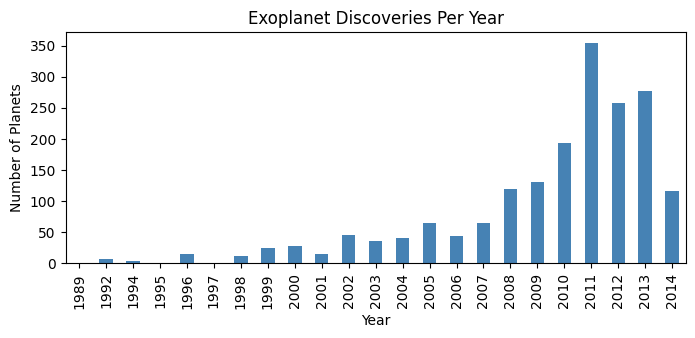

In [39]:
plt.figure(figsize=(8,3))
df.groupby('year')['number'].sum().plot(kind='bar', color='steelblue')
plt.title('Exoplanet Discoveries Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Planets')
plt.show()

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

transformer = ColumnTransformer(transformers=[
    ('scaler', StandardScaler(), c)
], remainder='passthrough')
df_scaled = transformer.fit_transform(df[c])


In [50]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df_imputed = imputer.fit_transform(df_scaled)

# Step 3 — Back to DataFrame
df_final = pd.DataFrame(df_imputed,
                        columns=c)

print("Missing before:", df[c].isnull().sum().sum())
print("Missing after :", df_final.isnull().sum().sum())

Missing before: 792
Missing after : 0


In [53]:
df_final.head(2)

,number,orbital_period,mass,distance,year
0,-0.633281,-0.066673,1.169584,-0.254782,-0.773308
1,-0.633281,-0.043387,-0.112234,-0.282694,-0.269611


In [57]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
X = df_final.drop(columns=['year'])
y = df_final['year']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("accuracy of knn ")
##-----------------------------------------------------------------------------------------------------------

MSE: 0.9298096527702291


In [61]:
import pandas as pd

# Convert the numpy array df_scaled back to a DataFrame to use dropna()
d= pd.DataFrame(df_scaled, columns=c)
d.dropna(inplace=True)
print(d.shape)

(498, 5)


In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
X = d.drop(columns=['year'])
y = d['year']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("accuracy of dropna ")

MSE: 1.1170035151889435
accuracy of dropna 
